<a href="https://colab.research.google.com/github/bsc1990/Cases-FIAP/blob/main/case_vinhos_fiap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## | Importação, Tratamento e Validação da Base


In [81]:
import pandas as pd

# Carregar datasets
base_vinho = pd.read_csv ('/content/base_WineQT.csv')

In [82]:
base_vinho.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [83]:
## Dimensão da base
print(base_vinho.shape)

(1143, 13)


In [84]:
# Criar uma cópia da base original
base_vinho_tratada = base_vinho.copy()

# Padronizar os nomes das colunas
base_vinho_tratada.columns = (
    base_vinho_tratada.columns
    .str.strip()                         # Remove espaços no início e no final
    .str.lower()                         # Converte para letras minúsculas
    .str.replace(r'\s+', '_', regex=True) # Substitui espaços por "_"
)

# Conferir os novos nomes
print(base_vinho_tratada.columns.tolist())

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality', 'id']


In [85]:
## Tratamento da Base

display(
    base_vinho_tratada.head(10).style.hide(axis="index")
)

fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,0
7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000,5,1
7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000,5,2
11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000,6,3
7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000,5,4
7.400000,0.660000,0.000000,1.800000,0.075000,13.000000,40.000000,0.997800,3.510000,0.560000,9.400000,5,5
7.900000,0.600000,0.060000,1.600000,0.069000,15.000000,59.000000,0.996400,3.300000,0.460000,9.400000,5,6
7.300000,0.650000,0.000000,1.200000,0.065000,15.000000,21.000000,0.994600,3.390000,0.470000,10.000000,7,7
7.800000,0.580000,0.020000,2.000000,0.073000,9.000000,18.000000,0.996800,3.360000,0.570000,9.500000,7,8
6.700000,0.580000,0.080000,1.800000,0.097000,15.000000,65.000000,0.995900,3.280000,0.540000,9.200000,5,10


In [86]:
## Remover coluna ID
base_vinho_tratada = base_vinho_tratada.drop(columns=['id'])

# Contar duplicidades
quantidade_duplicados = base_vinho_tratada.duplicated().sum()

print("Duplicidades:", quantidade_duplicados)

Duplicidades: 125


In [87]:
# Remover duplicidades
base_vinho_tratada = (
    base_vinho_tratada
    .drop_duplicates()
    .reset_index(drop=True)
)
print("Duplicidades:", quantidade_duplicados)
print("Base tratada:", base_vinho_tratada.shape)

Duplicidades: 125
Base tratada: (1018, 12)


In [88]:
# Verificar dados ausentes
print("Valores ausentes por coluna:")
print( base_vinho_tratada.isnull().sum())

# Verificar os tipos das colunas
print("\nTipos das colunas:")
print( base_vinho_tratada.dtypes)

# Verificar os valores da variável quality
print("\nValores encontrados em quality:")
print( base_vinho_tratada['quality'].value_counts().sort_index())

# Verificar valores negativos nas colunas numéricas
colunas_numericas = base_vinho_tratada.select_dtypes(include='number').columns
print("\nValores negativos por coluna:")
print( (base_vinho_tratada[colunas_numericas] < 0).sum())

Valores ausentes por coluna:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Tipos das colunas:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores encontrados em quality:
quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

Valores negativos por coluna:
fixed_acidity           0
volatile_acidity        0
citric_acid             

In [89]:
display(
    base_vinho_tratada.head(10))

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
5,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
6,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
7,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
8,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5
9,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,5


## | Criação e Validação de Variável Binária

In [90]:
# Criar a variável-alvo binária
base_vinho_tratada['alta_qualidade'] = (
    base_vinho_tratada['quality'] >= 7
).astype(int)

# Conferir a distribuição
print(base_vinho_tratada['alta_qualidade'].value_counts())

print("\nDistribuição percentual:")
print(
    base_vinho_tratada['alta_qualidade']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
display(
    base_vinho_tratada.head(10))

alta_qualidade
0    881
1    137
Name: count, dtype: int64

Distribuição percentual:
alta_qualidade
0    86.54
1    13.46
Name: proportion, dtype: float64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,alta_qualidade
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,0
5,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,0
6,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,1
7,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,1
8,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,0
9,5.6,0.615,0.00,1.6,0.089,16.0,59.0,0.9943,3.58,0.52,9.9,5,0


## || MODELO 1 - REGRESSÃO LOGÍSTICA
# | Separação de Variáveis

## ||Visão Geral da Base Tratada

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style='whitegrid',
    palette='deep'
)

print(
    "Quantidade de registros:",
    base_vinho_tratada.shape[0]
)

print(
    "Quantidade de colunas:",
    base_vinho_tratada.shape[1]
)

print("\nInformações da base:")
base_vinho_tratada.info()


# Estatísticas descritivas:

display(
    base_vinho_tratada
    .describe()
    .T
    .round(3)
)


# Verificação de dados ausentes:
resumo_qualidade_dados = pd.DataFrame({
    'tipo': base_vinho_tratada.dtypes,

    'valores_ausentes':
        base_vinho_tratada.isnull().sum(),

    'valores_unicos':
        base_vinho_tratada.nunique()
})

display(resumo_qualidade_dados)

Quantidade de registros: 1018
Quantidade de colunas: 13

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1018 non-null   float64
 1   volatile_acidity      1018 non-null   float64
 2   citric_acid           1018 non-null   float64
 3   residual_sugar        1018 non-null   float64
 4   chlorides             1018 non-null   float64
 5   free_sulfur_dioxide   1018 non-null   float64
 6   total_sulfur_dioxide  1018 non-null   float64
 7   density               1018 non-null   float64
 8   ph                    1018 non-null   float64
 9   sulphates             1018 non-null   float64
 10  alcohol               1018 non-null   float64
 11  quality               1018 non-null   int64  
 12  alta_qualidade        1018 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 103.5 

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1018.0,8.289,1.741,4.600,7.100,7.900,9.100,15.900
volatile_acidity,1018.0,0.534,0.183,0.120,0.390,0.520,0.645,1.580
citric_acid,1018.0,0.269,0.196,0.000,0.090,0.250,0.420,1.000
residual_sugar,1018.0,2.524,1.315,0.900,1.900,2.200,2.600,15.500
chlorides,1018.0,0.087,0.049,0.012,0.070,0.079,0.090,0.611
free_sulfur_dioxide,1018.0,15.649,10.177,1.000,7.000,13.000,21.000,68.000
total_sulfur_dioxide,1018.0,46.326,33.124,6.000,21.000,38.000,62.000,289.000
density,1018.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
ph,1018.0,3.312,0.158,2.740,3.210,3.310,3.400,4.010
sulphates,1018.0,0.657,0.168,0.330,0.550,0.620,0.720,2.000


,tipo,valores_ausentes,valores_unicos
fixed_acidity,float64,0,91
volatile_acidity,float64,0,135
citric_acid,float64,0,77
residual_sugar,float64,0,80
chlorides,float64,0,131
free_sulfur_dioxide,float64,0,53
total_sulfur_dioxide,float64,0,138
density,float64,0,388
ph,float64,0,87
sulphates,float64,0,89


Nota:

Após a etapa de tratamento, a base ficou com 1.018 registros. Não foram encontrados valores ausentes e todas as características utilizadas na análise são numéricas.

# || Distribuição de Notas e das Classes

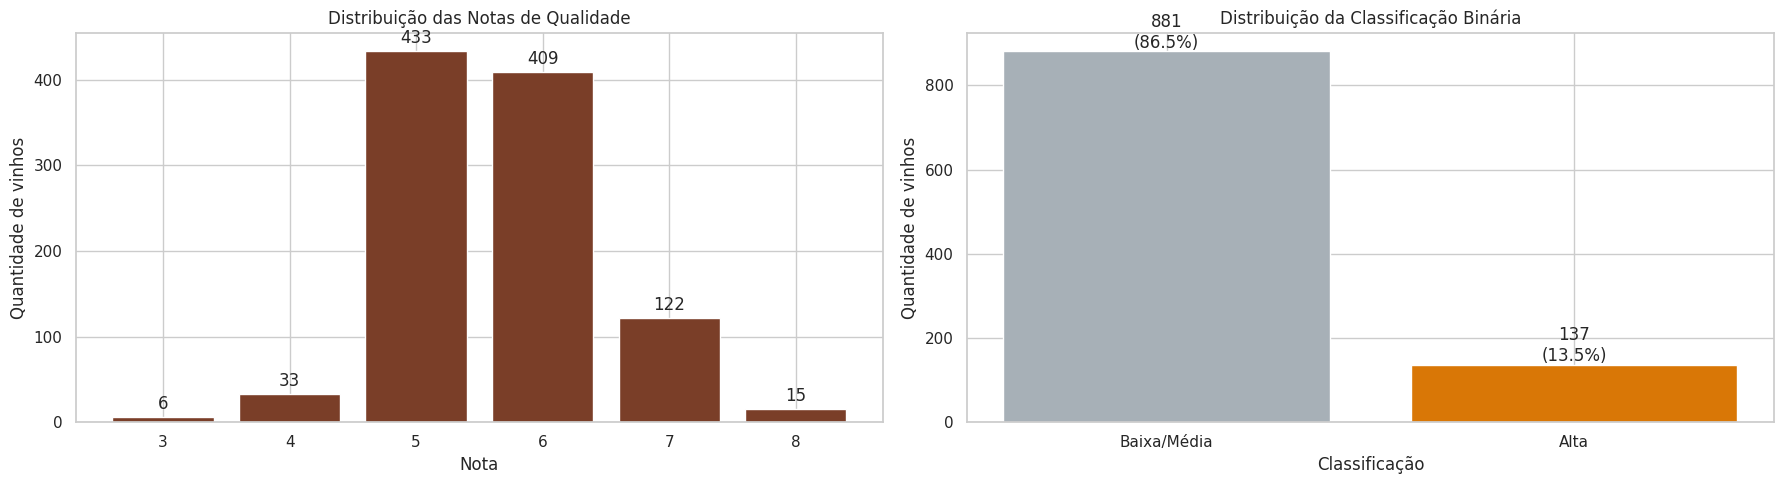

,classe,quantidade,percentual
0,Baixa/Média Qualidade,881,86.54%
1,Alta Qualidade,137,13.46%


In [92]:
contagem_notas = (
    base_vinho_tratada['quality']
    .value_counts()
    .sort_index()
)

contagem_classes = (
    base_vinho_tratada['alta_qualidade']
    .value_counts()
    .reindex([0, 1])
)

fig, eixos = plt.subplots(
    1,
    2,
    figsize=(18, 5)
)

# Distribuição das notas
barras_notas = eixos[0].bar(
    contagem_notas.index.astype(str),
    contagem_notas.values,
    color='#7A3E28'
)

eixos[0].bar_label(
    barras_notas,
    padding=3
)

eixos[0].set_title(
    'Distribuição das Notas de Qualidade'
)

eixos[0].set_xlabel('Nota')
eixos[0].set_ylabel('Quantidade de vinhos')

# Distribuição binária
nomes_classes = [
    'Baixa/Média',
    'Alta'
]

cores_classes = [
    '#A7B0B7',
    '#D97706'
]

barras_classes = eixos[1].bar(
    nomes_classes,
    contagem_classes.values,
    color=cores_classes
)

for barra, quantidade in zip(
    barras_classes,
    contagem_classes.values
):
    percentual = (
        quantidade
        / contagem_classes.sum()
    )

    eixos[1].text(
        barra.get_x()
        + barra.get_width() / 2,

        barra.get_height() + 8,

        f'{quantidade}\n({percentual:.1%})',

        ha='center'
    )

eixos[1].set_title(
    'Distribuição da Classificação Binária'
)

eixos[1].set_xlabel('Classificação')
eixos[1].set_ylabel('Quantidade de vinhos')

plt.tight_layout()
plt.show()


# Tabela
distribuicao_classes = pd.DataFrame({
    'classe': [
        'Baixa/Média Qualidade',
        'Alta Qualidade'
    ],

    'quantidade':
        contagem_classes.values,

    'percentual':
        contagem_classes.values
        / contagem_classes.sum()
})

display(
    distribuicao_classes.style.format({
        'percentual': '{:.2%}'
    })
)

Nota:

A maior parte da base está concentrada nas notas 5 e 6. Após transformar a qualidade em uma classificação binária, apenas 13,46% dos vinhos foram classificados como alta qualidade. Esse desbalanceamento foi considerado durante a preparação, treinamento e avaliação dos modelos.

# || Distribuição de Variáveis (Características dos Vinhos)

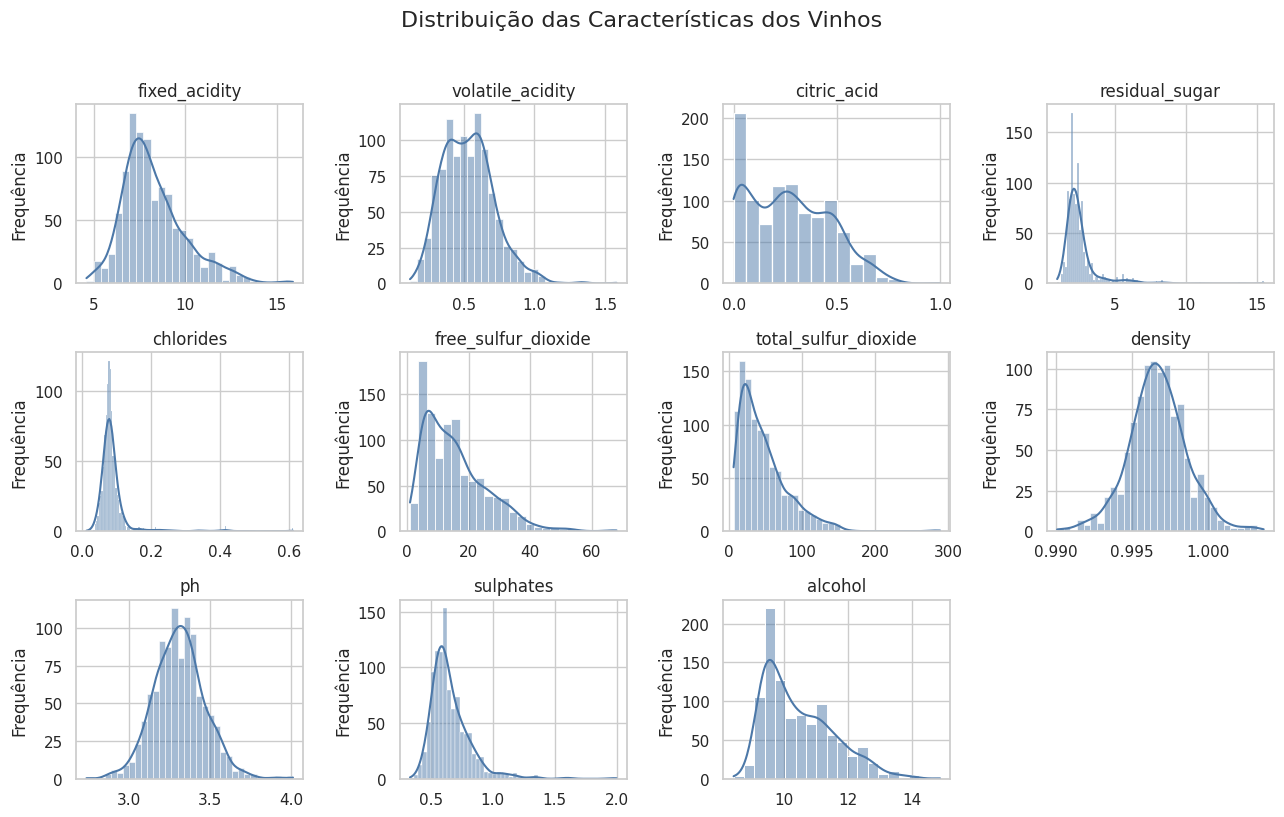

In [93]:
variaveis_explicativas = [
    coluna
    for coluna in base_vinho_tratada.columns
    if coluna not in [
        'quality',
        'alta_qualidade'
    ]
]

fig, eixos = plt.subplots(
    3,
    4,
    figsize=(13, 8)
)

eixos = eixos.flatten()

for indice, coluna in enumerate(
    variaveis_explicativas
):

    sns.histplot(
        data=base_vinho_tratada,
        x=coluna,
        kde=True,
        ax=eixos[indice],
        color='#4C78A8'
    )

    eixos[indice].set_title(coluna)
    eixos[indice].set_xlabel('')
    eixos[indice].set_ylabel('Frequência')

# Ocultar gráfico que sobrou
for indice in range(
    len(variaveis_explicativas),
    len(eixos)
):
    eixos[indice].set_visible(False)

plt.suptitle(
    'Distribuição das Características dos Vinhos',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

  # || Outliers



,quantidade_outliers,percentual_outliers
residual_sugar,95,9.33%
chlorides,71,6.97%
sulphates,41,4.03%
fixed_acidity,37,3.63%
total_sulfur_dioxide,33,3.24%
density,30,2.95%
ph,24,2.36%
free_sulfur_dioxide,16,1.57%
volatile_acidity,10,0.98%
alcohol,6,0.59%


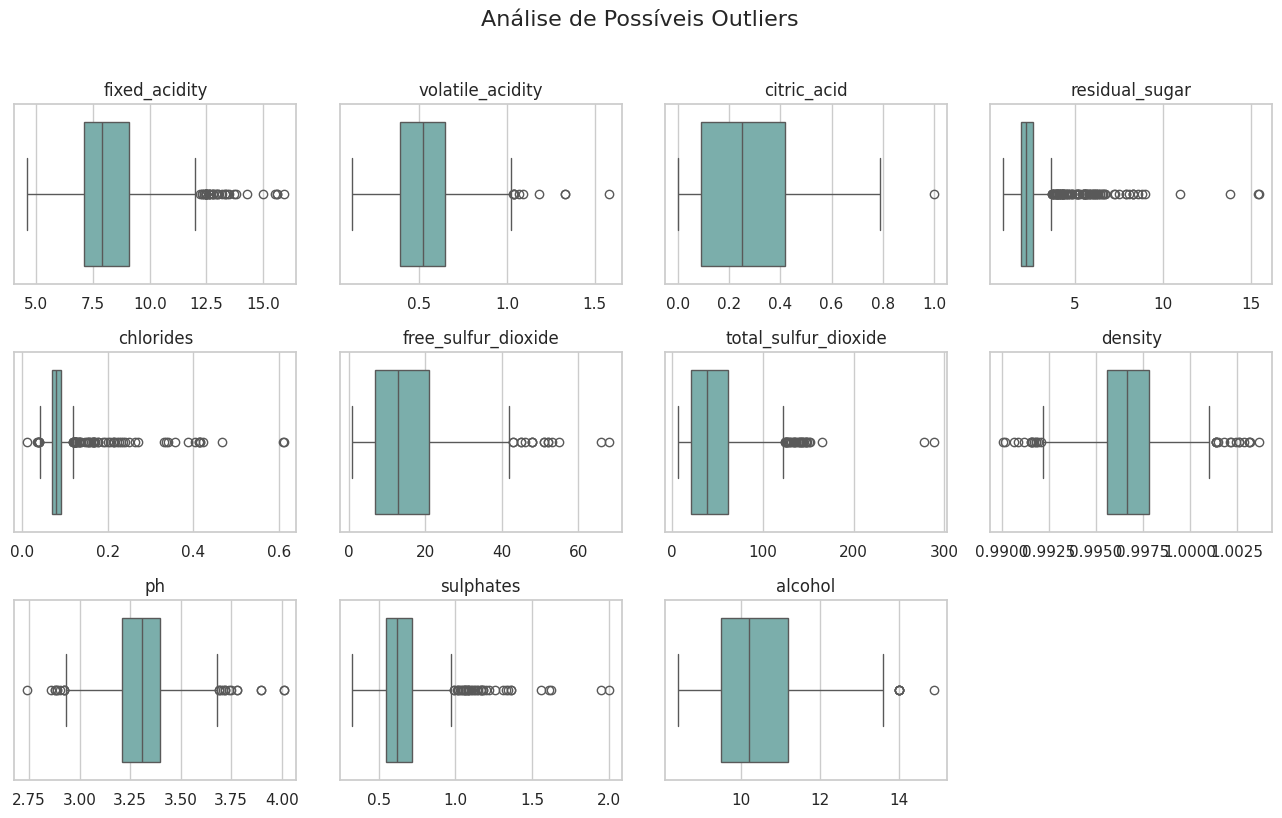

In [94]:
base_numerica = base_vinho_tratada[
    variaveis_explicativas
]

q1 = base_numerica.quantile(0.25)
q3 = base_numerica.quantile(0.75)

intervalo_interquartil = q3 - q1

limite_inferior = (
    q1 - 1.5 * intervalo_interquartil
)

limite_superior = (
    q3 + 1.5 * intervalo_interquartil
)

mascara_outliers = (
    base_numerica.lt(limite_inferior)
    | base_numerica.gt(limite_superior)
)

resumo_outliers = pd.DataFrame({
    'quantidade_outliers':
        mascara_outliers.sum(),

    'percentual_outliers':
        mascara_outliers.mean()
}).sort_values(
    by='percentual_outliers',
    ascending=False
)

display(
    resumo_outliers.style.format({
        'percentual_outliers': '{:.2%}'
    })
)


#Boxplots
fig, eixos = plt.subplots(
    3,
    4,
    figsize=(13, 8)
)

eixos = eixos.flatten()

for indice, coluna in enumerate(
    variaveis_explicativas
):

    sns.boxplot(
        data=base_vinho_tratada,
        x=coluna,
        ax=eixos[indice],
        color='#72B7B2'
    )

    eixos[indice].set_title(coluna)
    eixos[indice].set_xlabel('')

for indice in range(
    len(variaveis_explicativas),
    len(eixos)
):
    eixos[indice].set_visible(False)

plt.suptitle(
    'Análise de Possíveis Outliers',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

Nota:

Foram identificados possíveis outliers principalmente nas variáveis açúcar residual e cloretos. Como os valores estavam dentro de intervalos possíveis para a base e poderiam representar características reais dos vinhos, optou-se por mantê-los. A transformação das variáveis em faixas também ajudou a reduzir a influência dos valores extremos no modelo final.

## || Matriz de Correlação

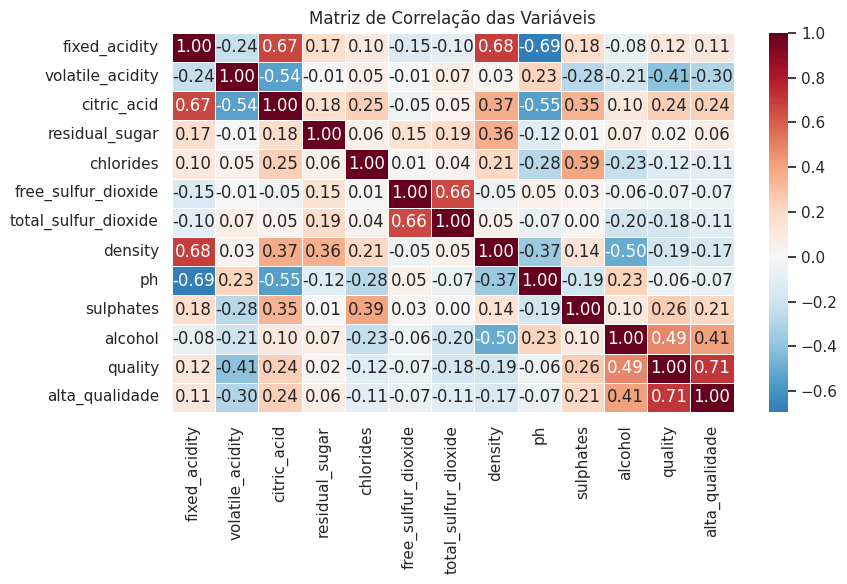

In [95]:
colunas_correlacao = (
    variaveis_explicativas
    + ['quality', 'alta_qualidade']
)

matriz_correlacao = (
    base_vinho_tratada[
        colunas_correlacao
    ]
    .corr()
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title(
    'Matriz de Correlação das Variáveis',
    fontsize=12
)

plt.tight_layout()
plt.show()

## || Correlação das Características com a Qualidade

,correlacao
alcohol,0.410
volatile_acidity,-0.302
citric_acid,0.237
sulphates,0.213
density,-0.166
total_sulfur_dioxide,-0.115
fixed_acidity,0.108
chlorides,-0.106
free_sulfur_dioxide,-0.067
ph,-0.065


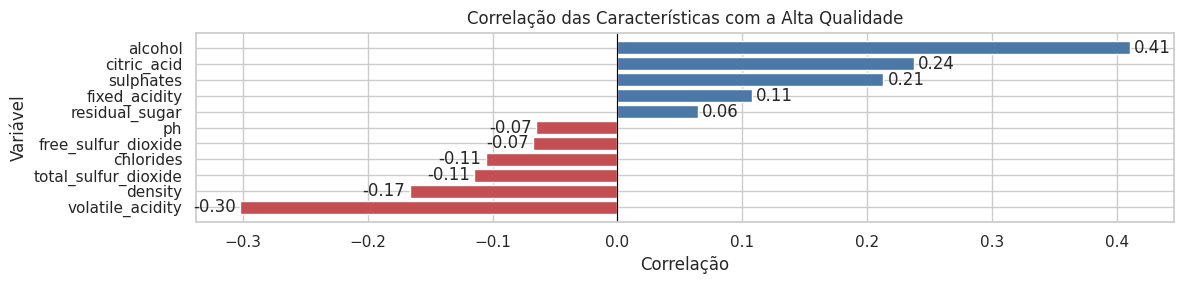

In [96]:

# Calcular a correlação das características com a alta qualidade
correlacao_alta_qualidade = (
    base_vinho_tratada
    .drop(columns=['quality'])
    .corr(numeric_only=True)['alta_qualidade']
    .drop('alta_qualidade')
)

# Tabela
display(
    correlacao_alta_qualidade
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame(
        name='correlacao'
    )
    .style.format({
        'correlacao': '{:.3f}'
    })
)


# Gráfico
correlacao_alta_qualidade = (
    matriz_correlacao['alta_qualidade']
    .drop([
        'alta_qualidade',
        'quality'
    ])
    .sort_values()
)

cores_correlacao = [
    '#C44E52' if valor < 0
    else '#4C78A8'
    for valor in correlacao_alta_qualidade.values
]

plt.figure(figsize=(12, 3))

barras = plt.barh(
    correlacao_alta_qualidade.index,
    correlacao_alta_qualidade.values,
    color=cores_correlacao
)

plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.bar_label(
    barras,
    fmt='%.2f',
    padding=3
)

plt.title(
    'Correlação das Características com a Alta Qualidade'
)

plt.xlabel('Correlação')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

## || Comparação das Médias por Classe

In [97]:
medias_por_classe = (
    base_vinho_tratada
    .groupby('alta_qualidade')[
        variaveis_explicativas
    ]
    .mean()
    .T
)

medias_por_classe.columns = [
    'baixa_media',
    'alta'
]

medias_por_classe[
    'variacao_percentual'
] = (
    (
        medias_por_classe['alta']
        / medias_por_classe['baixa_media']
    ) - 1
) * 100

medias_por_classe[
    'variacao_absoluta_percentual'
] = (
    medias_por_classe[
        'variacao_percentual'
    ].abs()
)

medias_por_classe = (
    medias_por_classe
    .sort_values(
        by='variacao_absoluta_percentual',
        ascending=False
    )
)

print ('Comparação das Médias por Classe')
display(
    medias_por_classe.drop(
        columns='variacao_absoluta_percentual'
    ).style.format({
        'baixa_media': '{:.3f}',
        'alta': '{:.3f}',
        'variacao_percentual': '{:+.2f}%'
    })
)

Comparação das Médias por Classe


,baixa_media,alta,variacao_percentual
citric_acid,0.250,0.387,+54.47%
volatile_acidity,0.555,0.393,-29.20%
total_sulfur_dioxide,47.827,36.672,-23.32%
chlorides,0.089,0.074,-16.82%
sulphates,0.643,0.747,+16.27%
alcohol,10.275,11.591,+12.81%
free_sulfur_dioxide,15.919,13.912,-12.60%
residual_sugar,2.491,2.739,+9.96%
fixed_acidity,8.214,8.765,+6.70%
ph,3.316,3.285,-0.91%


## || Relevância das Variáveis

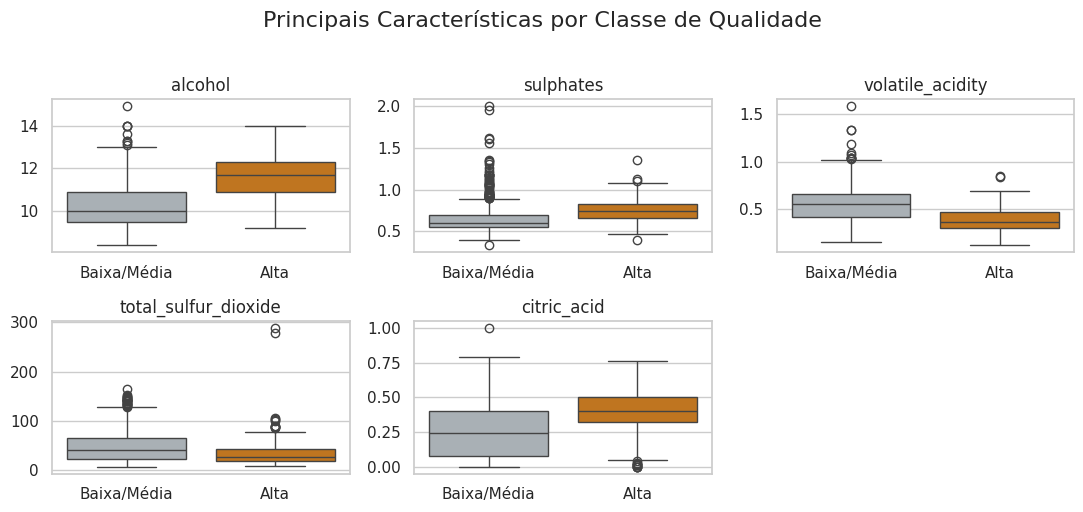

In [98]:
base_grafico = base_vinho_tratada.copy()

base_grafico['classe_qualidade'] = (
    base_grafico['alta_qualidade']
    .map({
        0: 'Baixa/Média',
        1: 'Alta'
    })
)

principais_variaveis = [
    'alcohol',
    'sulphates',
    'volatile_acidity',
    'total_sulfur_dioxide',
    'citric_acid'
]

fig, eixos = plt.subplots(
    2,
    3,
    figsize=(11, 5)
)

eixos = eixos.flatten()

for indice, coluna in enumerate(
    principais_variaveis
):

    sns.boxplot(
        data=base_grafico,
        x='classe_qualidade',
        y=coluna,
        order=[
            'Baixa/Média',
            'Alta'
        ],
        ax=eixos[indice],
        palette=[
            '#A7B0B7',
            '#D97706'
        ],
        hue='classe_qualidade',
        legend=False
    )

    eixos[indice].set_title(coluna)
    eixos[indice].set_xlabel('')
    eixos[indice].set_ylabel('')

eixos[-1].set_visible(False)

plt.suptitle(
    'Principais Características por Classe de Qualidade',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [99]:
from sklearn.model_selection import train_test_split

# Variáveis utilizadas para fazer a previsão
X = base_vinho_tratada.drop(
    columns=['quality', 'alta_qualidade']
)

# Variável que queremos prever
y = base_vinho_tratada['alta_qualidade']

# Separação entre treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensão do conjunto de treino:", X_treino.shape)
print("Dimensão do conjunto de teste:", X_teste.shape)

print("\nDistribuição da variável-alvo no treino:")
print(y_treino.value_counts())

print("\nDistribuição da variável-alvo no teste:")
print(y_teste.value_counts())

Dimensão do conjunto de treino: (814, 11)
Dimensão do conjunto de teste: (204, 11)

Distribuição da variável-alvo no treino:
alta_qualidade
0    704
1    110
Name: count, dtype: int64

Distribuição da variável-alvo no teste:
alta_qualidade
0    177
1     27
Name: count, dtype: int64


## || MODELO 1 - REGRESSÃO LOGÍSTICA

## | Pipeline da Regressão Logística

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_regressao_logistica = Pipeline([

    # Padronizar as escalas das variáveis
    ('padronizacao', StandardScaler()),

    # Criar o modelo
    ('modelo', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Treinar o modelo
pipeline_regressao_logistica.fit(
    X_treino,
    y_treino
)

print("Regressão Logística OK!")

Regressão Logística OK!


## | Previsões e Calculo de Métricas

In [101]:
# Previsão da classificação
y_pred_regressao = pipeline_regressao_logistica.predict(X_teste)

# Probabilidade de o vinho ser de alta qualidade
y_prob_regressao = pipeline_regressao_logistica.predict_proba(
    X_teste
)[:, 1]


# Cálculo de Métricas

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
resultado_regressao_logistica = pd.DataFrame({
    'modelo': ['Regressão Logística'],
    'acuracia': [
        accuracy_score(y_teste, y_pred_regressao)
        ],

    'precisao': [
                  precision_score(
                  y_teste,
                  y_pred_regressao,
                  zero_division=0
                  )
                ],

    'recall': [
                recall_score(y_teste, y_pred_regressao)
              ],

    'f1_score': [
                f1_score(y_teste, y_pred_regressao)
                ],

    'roc_auc': [
                roc_auc_score(y_teste, y_prob_regressao)
                ]
})

print ('Métricas')
display(
    resultado_regressao_logistica.style.format({
                                                'acuracia': '{:.2%}',
                                                'precisao': '{:.2%}',
                                                'recall': '{:.2%}',
                                                'f1_score': '{:.2%}',
                                                'roc_auc': '{:.2%}'
                                            })
)

Métricas


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%


## | Classificação

In [102]:
from sklearn.metrics import classification_report

print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_regressao,
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.79      0.86       177
       Alta Qualidade       0.36      0.78      0.49        27

             accuracy                           0.78       204
            macro avg       0.66      0.78      0.68       204
         weighted avg       0.88      0.78      0.81       204



## | Matriz de Confusão

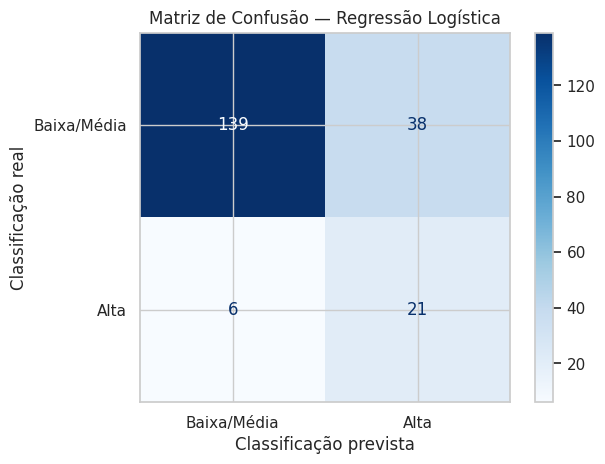

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_regressao,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Blues',
    values_format='d'
)

plt.title('Matriz de Confusão — Regressão Logística')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

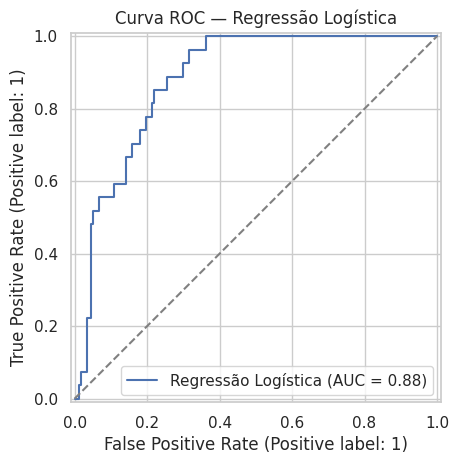

In [104]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_regressao,
    name='Regressão Logística'
)

plt.title('Curva ROC — Regressão Logística')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)
plt.show()

Nota:

A Regressão Logística identificou 77,78% dos vinhos de alta qualidade e apresentou um ROC-AUC de 88,18%, mostrando boa capacidade de diferenciar os dois grupos. Porém, a precisão ficou em 35,59%, o que mostra que vários vinhos foram classificados como alta qualidade sem de fato pertencerem a essa categoria. Portanto, neste primeiro momento, o modelo parece funcionar melhor como apoio em uma triagem inicial do que para definir sozinho a qualidade final do vinho.

## || MODELO 2 - KNN

In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## | Pipeline de KNN

In [106]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_knn = Pipeline([

  # Padronizar as variáveis
  ('padronizacao', StandardScaler()),

  # Criar o modelo KNN
  ('modelo', KNeighborsClassifier(
      n_neighbors=5,
      weights='distance'
  ))
])

# Treinar o modelo
pipeline_knn.fit(
    X_treino,
    y_treino
)

print("KNN OK!")


KNN OK!


## | Previsão e Cálculo de Métricas de KNN

In [107]:

# Previsão da classificação
y_pred_knn = pipeline_knn.predict(X_teste)

# Probabilidade de alta qualidade
y_prob_knn = pipeline_knn.predict_proba(
    X_teste
)[:, 1]

print("Previsões de KNN OK!")



# Cálculo de Métricas
resultado_knn = pd.DataFrame({
    'modelo': ['KNN'],

    'acuracia': [
        accuracy_score(y_teste, y_pred_knn)
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_knn,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_knn
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_knn
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_knn
        )
    ]
})

display(
    resultado_knn.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)


Previsões de KNN OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,KNN,88.24%,57.14%,44.44%,50.00%,86.47%


# | Classificação


In [108]:
print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_knn,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.92      0.95      0.93       177
       Alta Qualidade       0.57      0.44      0.50        27

             accuracy                           0.88       204
            macro avg       0.74      0.70      0.72       204
         weighted avg       0.87      0.88      0.88       204



# | Matriz de Confusão

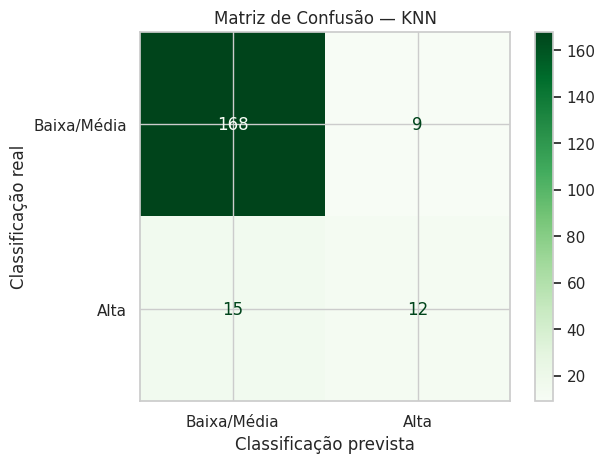

In [109]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_knn,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Greens',
    values_format='d'
)

plt.title('Matriz de Confusão — KNN')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

# | Curva ROC

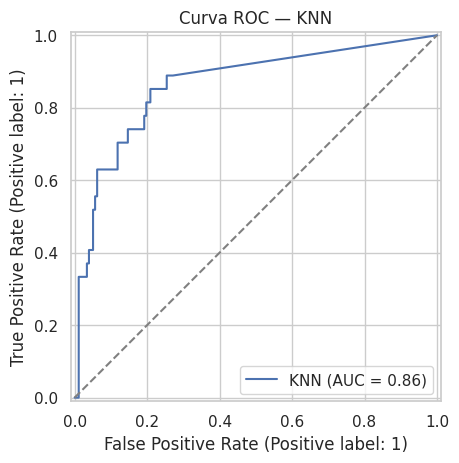

In [110]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_knn,
    name='KNN'
)

plt.title('Curva ROC — KNN')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

# | Comparação com Regressão Logística

In [111]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn
], ignore_index=True)

print ('Comparação entre KNN e Regressão Logística')
display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Comparação entre KNN e Regressão Logística


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%


Nota:

O KNN teve acurácia de 88,24% e precisão de 57,14%, resultados superiores aos da Regressão Logística. Porém o modelo identificou apenas 44,44% dos vinhos de alta qualidade, deixando de encontrar 15 dos 27 vinhos superiores presentes na base de teste. Dessa forma, o KNN mostrou ser mais preciso quando classifica um vinho como alta qualidade, mas apresentou uma capacidade menor de identificar todos os vinhos que pertencem a essa categoria.


## || MODELO 3 - SVM

## | Pipeline de SVM

In [112]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline_svm = Pipeline([

    # Padronizar as variáveis
    ('padronizacao', StandardScaler()),

    # Criar o modelo SVM
    ('modelo', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

# Treinar o modelo
pipeline_svm.fit(
    X_treino,
    y_treino
)

print("SVM OK!")

SVM OK!


## | Previsão e Cálculo de Métricas

In [113]:
# Previsão da classificação
y_pred_svm = pipeline_svm.predict(X_teste)

# Probabilidade de alta qualidade
y_prob_svm = pipeline_svm.predict_proba(
    X_teste
)[:, 1]

print("Previsões do SVM OK!")



#Cálculo de Métricas
resultado_svm = pd.DataFrame({
    'modelo': ['SVM'],

    'acuracia': [
        accuracy_score(y_teste, y_pred_svm)
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_svm,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_svm
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_svm
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_svm
        )
    ]
})

display(
    resultado_svm.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)



Previsões do SVM OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,SVM,82.84%,41.67%,74.07%,53.33%,90.19%


## | Classificação

In [114]:

print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_svm,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.84      0.89       177
       Alta Qualidade       0.42      0.74      0.53        27

             accuracy                           0.83       204
            macro avg       0.69      0.79      0.71       204
         weighted avg       0.88      0.83      0.85       204



## | Matriz de Confusão

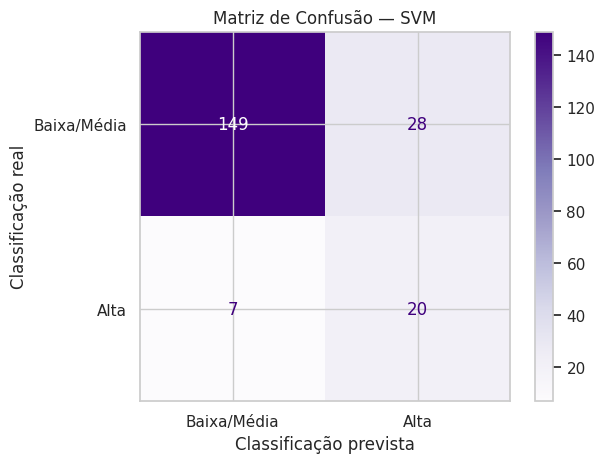

In [115]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_svm,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Purples',
    values_format='d'
)

plt.title('Matriz de Confusão — SVM')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

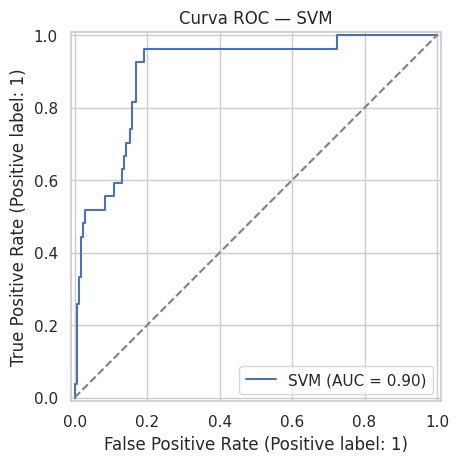

In [116]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_svm,
    name='SVM'
)

plt.title('Curva ROC — SVM')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

## | Comparação

In [117]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn,
    resultado_svm
], ignore_index=True)

display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%
2,SVM,82.84%,41.67%,74.07%,53.33%,90.19%


Nota:

O SVM teve acurácia de 82,84% e identificou 74,07% dos vinhos de alta qualidade. Apesar de o recall ter ficado um pouco abaixo do resultado da Regressão Logística, o modelo reduziu a quantidade de falsos positivos e aumentou a precisão para 41,67%. Além disso, apresentou os melhores resultados de F1-score e ROC-AUC entre os três modelos testados até o momento. Com isso, o SVM se mostrou o modelo mais equilibrado nesta primeira comparação.


## || MODELO 4 - Random Forest

## | Pipeline de Random Forest

In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline_random_forest = Pipeline([

    ('modelo', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Treinar o modelo
pipeline_random_forest.fit(
    X_treino,
    y_treino
)

print("Random Forest OK!")

Random Forest OK!


## | Previsão e Cálculo de Métricas

In [119]:
# Previsão da classificação
y_pred_random_forest = pipeline_random_forest.predict(
    X_teste
)

# Probabilidade de alta qualidade
y_prob_random_forest = pipeline_random_forest.predict_proba(
    X_teste
)[:, 1]

print("Previsões do Random Forest OK!")



#Cálculo de Métricas
resultado_random_forest = pd.DataFrame({
    'modelo': ['Random Forest'],

    'acuracia': [
        accuracy_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'precisao': [
        precision_score(
            y_teste,
            y_pred_random_forest,
            zero_division=0
        )
    ],

    'recall': [
        recall_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'f1_score': [
        f1_score(
            y_teste,
            y_pred_random_forest
        )
    ],

    'roc_auc': [
        roc_auc_score(
            y_teste,
            y_prob_random_forest
        )
    ]
})

display(
    resultado_random_forest.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Previsões do Random Forest OK!


,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Random Forest,90.69%,75.00%,44.44%,55.81%,92.43%


## | Classificação

In [120]:
print('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_random_forest,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.92      0.98      0.95       177
       Alta Qualidade       0.75      0.44      0.56        27

             accuracy                           0.91       204
            macro avg       0.84      0.71      0.75       204
         weighted avg       0.90      0.91      0.90       204



## | Matriz de Confusão

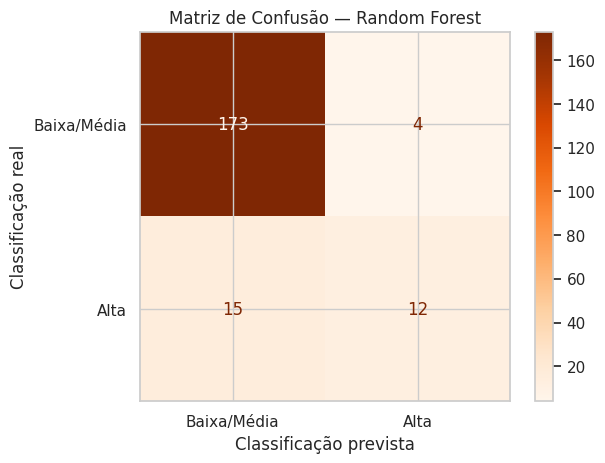

In [121]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_random_forest,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Oranges',
    values_format='d'
)

plt.title('Matriz de Confusão — Random Forest')
plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

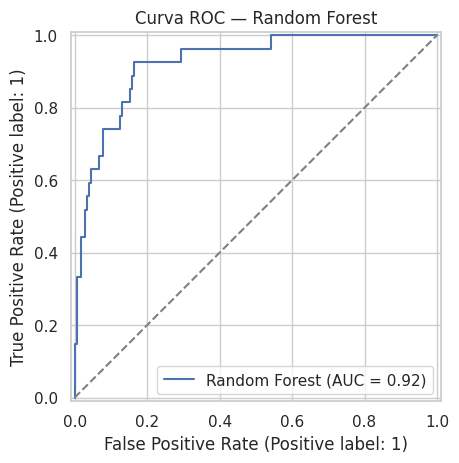

In [122]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_random_forest,
    name='Random Forest'
)

plt.title('Curva ROC — Random Forest')
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.show()

## | Variáveis

,variavel,importancia
10,alcohol,21.94%
1,volatile_acidity,13.24%
9,sulphates,13.06%
2,citric_acid,10.30%
7,density,8.49%
4,chlorides,7.61%
6,total_sulfur_dioxide,6.51%
0,fixed_acidity,5.47%
3,residual_sugar,4.78%
8,ph,4.52%


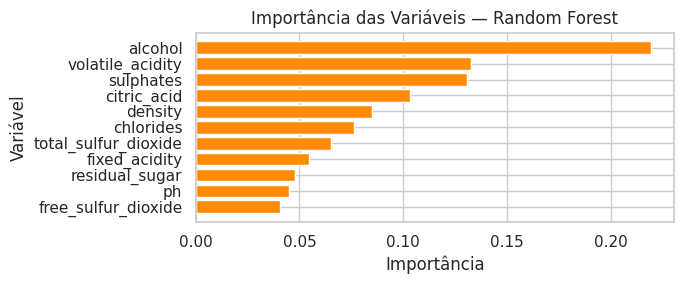

In [123]:
# Acessar o modelo dentro do pipeline
modelo_random_forest = (
    pipeline_random_forest.named_steps['modelo']
)

# Criar tabela com a importância das variáveis
importancia_variaveis = pd.DataFrame({
    'variavel': X_treino.columns,
    'importancia': modelo_random_forest.feature_importances_
}).sort_values(
    by='importancia',
    ascending=False
)

display(
    importancia_variaveis.style.format({
        'importancia': '{:.2%}'
    })
)



#Gráfico
importancia_grafico = importancia_variaveis.sort_values(
    by='importancia',
    ascending=True
)

plt.figure(figsize=(7, 3))

plt.barh(
    importancia_grafico['variavel'],
    importancia_grafico['importancia'],
    color='darkorange'
)

plt.title('Importância das Variáveis — Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

## | Comparação

In [124]:
comparacao_modelos = pd.concat([
    resultado_regressao_logistica,
    resultado_knn,
    resultado_svm,
    resultado_random_forest
], ignore_index=True)

display(
    comparacao_modelos.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

,modelo,acuracia,precisao,recall,f1_score,roc_auc
0,Regressão Logística,78.43%,35.59%,77.78%,48.84%,88.18%
1,KNN,88.24%,57.14%,44.44%,50.00%,86.47%
2,SVM,82.84%,41.67%,74.07%,53.33%,90.19%
3,Random Forest,90.69%,75.00%,44.44%,55.81%,92.43%


Nota:

O Random Forest apresentou os melhores resultados de acurácia, precisão, F1-score e ROC-AUC se comparado com os três outros modelos testados. O modelo teve uma precisão de 75%, o que mostra uma boa taxa de acerto entre os vinhos classificados como alta qualidade. Porém, conseguiu identificar apenas 44,44% dos vinhos que realmente pertenciam a essa categoria. Dessa forma, o Random Forest se mostrou mais confiável quando aponta um vinho como alta qualidade, mas ainda deixa passar uma quantidade relevante de vinhos superiores.

## || Testes e Validações

## | Validação Cruzada

In [125]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import make_scorer
from sklearn.dummy import DummyClassifier

# Criar as métricas de avaliação
metricas_cv = {
    'acuracia': 'accuracy',

    'precisao': make_scorer(
        precision_score,
        zero_division=0
    ),

    'recall': make_scorer(
        recall_score,
        zero_division=0
    ),

    'f1_score': make_scorer(
        f1_score,
        zero_division=0
    ),

    'roc_auc': 'roc_auc'
}

# Criar cinco divisões estratificadas
validacao_cruzada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelos que serão avaliados
modelos_cv = {
    'Dummy — Referência': DummyClassifier(
        strategy='most_frequent'
    ),

    'Regressão Logística': pipeline_regressao_logistica,

    'KNN': pipeline_knn,

    'SVM': pipeline_svm,

    'Random Forest': pipeline_random_forest
}


#Executar Validação Cruzada

resultados_cv = []

for nome_modelo, modelo in modelos_cv.items():

    scores = cross_validate(
        estimator=modelo,
        X=X_treino,
        y=y_treino,
        cv=validacao_cruzada,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_cv.append({
        'modelo': nome_modelo,

        'acuracia_media':
            scores['test_acuracia'].mean(),

        'precisao_media':
            scores['test_precisao'].mean(),

        'recall_medio':
            scores['test_recall'].mean(),

        'f1_medio':
            scores['test_f1_score'].mean(),

        'roc_auc_medio':
            scores['test_roc_auc'].mean(),

        'f1_desvio':
            scores['test_f1_score'].std(),

        'roc_auc_desvio':
            scores['test_roc_auc'].std()
    })

resultados_validacao_cruzada = pd.DataFrame(
    resultados_cv
)

# Visualizar Resultados
resultados_validacao_cruzada = (
    resultados_validacao_cruzada
    .sort_values(
        by='f1_medio',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultados_validacao_cruzada.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}',
        'roc_auc_desvio': '{:.2%}'
    })
)

,modelo,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio,roc_auc_desvio
0,Regressão Logística,79.24%,37.84%,82.73%,51.85%,87.17%,3.11%,3.29%
1,SVM,80.71%,38.75%,73.64%,50.63%,86.28%,4.68%,4.60%
2,Random Forest,87.59%,56.94%,36.36%,43.72%,87.01%,11.81%,4.43%
3,KNN,86.73%,51.67%,36.36%,42.43%,78.64%,10.22%,6.09%
4,Dummy — Referência,86.49%,0.00%,0.00%,0.00%,50.00%,0.00%,0.00%


Nota:

Após a validação cruzada, a Regressão Logística apresentou o maior recall médio, com 82,73%, o melhor F1-score, com 51,85%, e a menor variação entre as diferentes divisões da base. O SVM ficou próximo e também se mostrou uma alternativa relevante. Já o Random Forest apresentou a maior acurácia e precisão, mas identificou apenas 36,36% dos vinhos de alta qualidade e apresentou maior variação entre os testes.

Obs.: Esses resultados reforçam a importância de não escolher o modelo com base em uma única divisão dos dados.

## || Teste de Features

In [126]:
# Criar uma cópia das variáveis originais
X_features_derivadas = X_treino.copy()

# Relação entre dióxido de enxofre livre e total
X_features_derivadas['free_total_so2_ratio'] = (
    X_features_derivadas['free_sulfur_dioxide']
    / (
        X_features_derivadas['total_sulfur_dioxide']
        + 0.000001
    )
)

# Quantidade estimada de dióxido de enxofre combinado
X_features_derivadas['bound_sulfur_dioxide'] = (
    X_features_derivadas['total_sulfur_dioxide']
    - X_features_derivadas['free_sulfur_dioxide']
)

# Relação entre acidez volátil e acidez fixa
X_features_derivadas['volatile_fixed_acidity_ratio'] = (
    X_features_derivadas['volatile_acidity']
    / (
        X_features_derivadas['fixed_acidity']
        + 0.000001
    )
)

print("Quantidade de features originais:", X.shape[1])
print(
    "Quantidade após a criação das features:",
    X_features_derivadas.shape[1]
)

display(X_features_derivadas.head())

Quantidade de features originais: 11
Quantidade após a criação das features: 14


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,free_total_so2_ratio,bound_sulfur_dioxide,volatile_fixed_acidity_ratio
814,7.0,0.42,0.19,2.30,0.071,18.0,36.0,0.99476,3.39,0.56,10.9,0.500000,18.0,0.060000
628,9.1,0.29,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,0.481481,14.0,0.031868
883,7.6,0.30,0.42,2.00,0.052,6.0,24.0,0.99630,3.44,0.82,11.9,0.250000,18.0,0.039474
547,11.7,0.28,0.47,1.70,0.054,17.0,32.0,0.99686,3.15,0.67,10.6,0.531250,15.0,0.023932
138,7.0,0.49,0.49,5.60,0.060,26.0,121.0,0.99740,3.34,0.76,10.5,0.214876,95.0,0.070000


## | Validação dos Modelos com as Features e Comparação com as Features Originais

In [127]:
modelos_teste_features = {
    'Regressão Logística': pipeline_regressao_logistica,
    'KNN': pipeline_knn,
    'SVM': pipeline_svm,
    'Random Forest': pipeline_random_forest
}

resultados_features = []

for nome_modelo, modelo in modelos_teste_features.items():

    scores = cross_validate(
        estimator=modelo,
        X=X_features_derivadas,
        y=y_treino,
        cv=validacao_cruzada,
        scoring=metricas_cv,
        n_jobs=-1
    )

    resultados_features.append({
        'modelo': nome_modelo,

        'acuracia_media':
            scores['test_acuracia'].mean(),

        'precisao_media':
            scores['test_precisao'].mean(),

        'recall_medio':
            scores['test_recall'].mean(),

        'f1_medio':
            scores['test_f1_score'].mean(),

        'roc_auc_medio':
            scores['test_roc_auc'].mean(),

        'f1_desvio':
            scores['test_f1_score'].std(),

        'roc_auc_desvio':
            scores['test_roc_auc'].std()
    })

resultados_features_derivadas = pd.DataFrame(
    resultados_features
)


# Comparação com as Features Originais
resultados_originais = (
    resultados_validacao_cruzada[
        resultados_validacao_cruzada['modelo']
        != 'Dummy — Referência'
    ]
)

comparacao_features = resultados_originais.merge(
    resultados_features_derivadas,
    on='modelo',
    suffixes=('_original', '_features')
)

comparacao_features['variacao_f1'] = (
    comparacao_features['f1_medio_features']
    - comparacao_features['f1_medio_original']
)

comparacao_features['variacao_roc_auc'] = (
    comparacao_features['roc_auc_medio_features']
    - comparacao_features['roc_auc_medio_original']
)

comparacao_features['variacao_recall'] = (
    comparacao_features['recall_medio_features']
    - comparacao_features['recall_medio_original']
)

colunas_comparacao = [
    'modelo',
    'f1_medio_original',
    'f1_medio_features',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_features',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_features',
    'variacao_roc_auc'
]

display(
    comparacao_features[
        colunas_comparacao
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_features': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_features': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_features': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}'
    })
)

,modelo,f1_medio_original,f1_medio_features,variacao_f1,recall_medio_original,recall_medio_features,variacao_recall,roc_auc_medio_original,roc_auc_medio_features,variacao_roc_auc
0,Regressão Logística,51.85%,51.50%,-0.35%,82.73%,82.73%,+0.00%,87.17%,87.64%,+0.47%
1,SVM,50.63%,51.69%,+1.06%,73.64%,76.36%,+2.73%,86.28%,86.87%,+0.58%
2,Random Forest,43.72%,45.63%,+1.91%,36.36%,39.09%,+2.73%,87.01%,87.72%,+0.71%
3,KNN,42.43%,48.53%,+6.10%,36.36%,42.73%,+6.36%,78.64%,79.69%,+1.05%


Nota:

A criação das novas features trouxe ganhos para o SVM, o Random Forest e principalmente para o KNN. O KNN apresentou aumento de 6,10 pontos percentuais no F1-score e de 6,36 pontos percentuais no recall. A Regressão Logística teve uma pequena redução no F1-score, enquanto seu recall permaneceu estável. Apesar da melhora do KNN, seu recall e ROC-AUC ainda permaneceram abaixo dos resultados dos modelos lineares, indicando que as novas características ajudaram, mas não foram suficientes para definir o modelo final.

## | Seleção de Features

In [128]:
from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.model_selection import GridSearchCV

## | Pipeline e Teste

In [129]:
pipelines_selecao = {

    'Regressão Logística': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]),

    'KNN': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            KNeighborsClassifier(
                n_neighbors=5,
                weights='distance'
            )
        )
    ]),

    'SVM': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'padronizacao',
            StandardScaler()
        ),
        (
            'modelo',
            SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            )
        )
    ]),

    'Random Forest': Pipeline([
        (
            'selecao',
            SelectKBest(score_func=f_classif)
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}


# Teste de diferentes quantidades
quantidades_features = {
    'selecao__k': [4, 5, 6, 7, 8, 9, 10, 11]
}

resultados_selecao = []
melhores_modelos_selecao = {}

for nome_modelo, pipeline in pipelines_selecao.items():

    busca_features = GridSearchCV(
        estimator=pipeline,
        param_grid=quantidades_features,
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_cruzada,
        n_jobs=-1
    )

    busca_features.fit(
    X_treino,
    y_treino
)

    melhores_modelos_selecao[nome_modelo] = (
        busca_features.best_estimator_
    )

    melhor_indice = busca_features.best_index_

    seletor = (
        busca_features
        .best_estimator_
        .named_steps['selecao']
    )

    features_selecionadas = X_treino.columns[
    seletor.get_support()
    ].tolist()

    resultados_selecao.append({
        'modelo': nome_modelo,

        'quantidade_features':
            busca_features.best_params_['selecao__k'],

        'features_selecionadas':
            ', '.join(features_selecionadas),

        'acuracia_media':
            busca_features.cv_results_[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_media':
            busca_features.cv_results_[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_medio':
            busca_features.cv_results_[
                'mean_test_recall'
            ][melhor_indice],

        'f1_medio':
            busca_features.cv_results_[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_medio':
            busca_features.cv_results_[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            busca_features.cv_results_[
                'std_test_f1_score'
            ][melhor_indice]
    })

resultados_selecao_features = pd.DataFrame(
    resultados_selecao
)

#Visualização dos resultados
display(
    resultados_selecao_features.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)

,modelo,quantidade_features,features_selecionadas,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio
0,Regressão Logística,10,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, sulphates, alcohol",79.61%,38.29%,82.73%,52.28%,86.83%,2.89%
1,KNN,9,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, total_sulfur_dioxide, density, sulphates, alcohol",88.33%,59.44%,41.82%,48.99%,79.87%,11.95%
2,SVM,11,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol",80.71%,38.75%,73.64%,50.63%,86.28%,4.68%
3,Random Forest,5,"volatile_acidity, citric_acid, density, sulphates, alcohol",87.22%,52.62%,43.64%,47.46%,86.04%,11.50%


## | Comparação

In [130]:
comparacao_selecao = resultados_originais.merge(
    resultados_selecao_features,
    on='modelo',
    suffixes=('_original', '_selecao')
)

comparacao_selecao['variacao_f1'] = (
    comparacao_selecao['f1_medio_selecao']
    - comparacao_selecao['f1_medio_original']
)

comparacao_selecao['variacao_recall'] = (
    comparacao_selecao['recall_medio_selecao']
    - comparacao_selecao['recall_medio_original']
)

comparacao_selecao['variacao_roc_auc'] = (
    comparacao_selecao['roc_auc_medio_selecao']
    - comparacao_selecao['roc_auc_medio_original']
)

colunas_selecao = [
    'modelo',
    'quantidade_features',
    'f1_medio_original',
    'f1_medio_selecao',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_selecao',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_selecao',
    'variacao_roc_auc',
    'features_selecionadas'
]

display(
    comparacao_selecao[
        colunas_selecao
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_selecao': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_selecao': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_selecao': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}'
    })
)

,modelo,quantidade_features,f1_medio_original,f1_medio_selecao,variacao_f1,recall_medio_original,recall_medio_selecao,variacao_recall,roc_auc_medio_original,roc_auc_medio_selecao,variacao_roc_auc,features_selecionadas
0,Regressão Logística,10,51.85%,52.28%,+0.43%,82.73%,82.73%,+0.00%,87.17%,86.83%,-0.34%,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, sulphates, alcohol"
1,SVM,11,50.63%,50.63%,+0.00%,73.64%,73.64%,+0.00%,86.28%,86.28%,+0.00%,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density, ph, sulphates, alcohol"
2,Random Forest,5,43.72%,47.46%,+3.74%,36.36%,43.64%,+7.27%,87.01%,86.04%,-0.96%,"volatile_acidity, citric_acid, density, sulphates, alcohol"
3,KNN,9,42.43%,48.99%,+6.57%,36.36%,41.82%,+5.45%,78.64%,79.87%,+1.23%,"fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides, total_sulfur_dioxide, density, sulphates, alcohol"


Nota:

A seleção de features trouxe uma pequena melhora para a Regressão Logística, que passou a utilizar dez características, enquanto o SVM manteve todas as variáveis originais. O Random Forest apresentou melhora de 3,74 pontos percentuais no F1-score e de 7,27 pontos percentuais no recall utilizando apenas cinco características. O KNN apresentou o maior ganho no F1-score, de 6,57 pontos percentuais, utilizando nove features, mas continuou com recall baixo e maior variação entre os testes. Dessa forma, a seleção ajudou a simplificar os modelos, mas ainda não foi suficiente para definir o melhor resultado.

## | Teste de Criação de Faixas

## | Pipeline com Faixas

In [131]:
from sklearn.preprocessing import KBinsDiscretizer

pipelines_faixas = {

    'Regressão Logística': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            LogisticRegression(
                max_iter=1000,
                class_weight='balanced',
                random_state=42
            )
        )
    ]),

    'KNN': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            KNeighborsClassifier(
                n_neighbors=5,
                weights='distance'
            )
        )
    ]),

    'SVM': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            SVC(
                kernel='rbf',
                C=1.0,
                gamma='scale',
                class_weight='balanced',
                probability=True,
                random_state=42
            )
        )
    ]),

    'Random Forest': Pipeline([
        (
            'faixas',
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ),
        (
            'modelo',
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features='sqrt',
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

## | Teste

In [132]:
parametros_faixas = {
    'faixas__n_bins': [3, 4, 5],
    'faixas__strategy': [
        'quantile',
        'kmeans'
    ]
}

resultados_teste_faixas = []
melhores_modelos_faixas = {}

for nome_modelo, pipeline in pipelines_faixas.items():

    busca_faixas = GridSearchCV(
        estimator=pipeline,
        param_grid=parametros_faixas,
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_cruzada,
        n_jobs=-1
    )

    busca_faixas.fit(
    X_treino,
    y_treino
)

    melhores_modelos_faixas[nome_modelo] = (
        busca_faixas.best_estimator_
    )

    melhor_indice = busca_faixas.best_index_

    resultados_teste_faixas.append({
        'modelo': nome_modelo,

        'quantidade_faixas':
            busca_faixas.best_params_[
                'faixas__n_bins'
            ],

        'estrategia':
            busca_faixas.best_params_[
                'faixas__strategy'
            ],

        'acuracia_media':
            busca_faixas.cv_results_[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_media':
            busca_faixas.cv_results_[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_medio':
            busca_faixas.cv_results_[
                'mean_test_recall'
            ][melhor_indice],

        'f1_medio':
            busca_faixas.cv_results_[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_medio':
            busca_faixas.cv_results_[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            busca_faixas.cv_results_[
                'std_test_f1_score'
            ][melhor_indice]
    })

resultados_faixas = pd.DataFrame(
    resultados_teste_faixas
)

# Visualização
print('Teste')
display(
    resultados_faixas.style.format({
        'acuracia_media': '{:.2%}',
        'precisao_media': '{:.2%}',
        'recall_medio': '{:.2%}',
        'f1_medio': '{:.2%}',
        'roc_auc_medio': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)


Teste


,modelo,quantidade_faixas,estrategia,acuracia_media,precisao_media,recall_medio,f1_medio,roc_auc_medio,f1_desvio
0,Regressão Logística,5,quantile,81.94%,41.31%,78.18%,53.88%,86.16%,6.48%
1,KNN,3,quantile,87.22%,54.01%,39.09%,45.06%,77.85%,8.72%
2,SVM,3,quantile,82.68%,42.07%,73.64%,53.47%,85.83%,4.56%
3,Random Forest,5,kmeans,88.33%,56.42%,59.09%,57.53%,88.21%,6.32%


## | Comparação com Variáveis Contínuas

In [133]:
comparacao_faixas = resultados_originais.merge(
    resultados_faixas,
    on='modelo',
    suffixes=('_original', '_faixas')
)

comparacao_faixas['variacao_f1'] = (
    comparacao_faixas['f1_medio_faixas']
    - comparacao_faixas['f1_medio_original']
)

comparacao_faixas['variacao_recall'] = (
    comparacao_faixas['recall_medio_faixas']
    - comparacao_faixas['recall_medio_original']
)

comparacao_faixas['variacao_roc_auc'] = (
    comparacao_faixas['roc_auc_medio_faixas']
    - comparacao_faixas['roc_auc_medio_original']
)

colunas_faixas = [
    'modelo',
    'quantidade_faixas',
    'estrategia',
    'f1_medio_original',
    'f1_medio_faixas',
    'variacao_f1',
    'recall_medio_original',
    'recall_medio_faixas',
    'variacao_recall',
    'roc_auc_medio_original',
    'roc_auc_medio_faixas',
    'variacao_roc_auc',
    'f1_desvio_faixas'
]

print('Comparação com Variáveis Contínuas')
display(
    comparacao_faixas[
        colunas_faixas
    ].style.format({
        'f1_medio_original': '{:.2%}',
        'f1_medio_faixas': '{:.2%}',
        'variacao_f1': '{:+.2%}',
        'recall_medio_original': '{:.2%}',
        'recall_medio_faixas': '{:.2%}',
        'variacao_recall': '{:+.2%}',
        'roc_auc_medio_original': '{:.2%}',
        'roc_auc_medio_faixas': '{:.2%}',
        'variacao_roc_auc': '{:+.2%}',
        'f1_desvio_faixas': '{:.2%}'
    })
)

Comparação com Variáveis Contínuas


,modelo,quantidade_faixas,estrategia,f1_medio_original,f1_medio_faixas,variacao_f1,recall_medio_original,recall_medio_faixas,variacao_recall,roc_auc_medio_original,roc_auc_medio_faixas,variacao_roc_auc,f1_desvio_faixas
0,Regressão Logística,5,quantile,51.85%,53.88%,+2.03%,82.73%,78.18%,-4.55%,87.17%,86.16%,-1.01%,6.48%
1,SVM,3,quantile,50.63%,53.47%,+2.84%,73.64%,73.64%,+0.00%,86.28%,85.83%,-0.45%,4.56%
2,Random Forest,5,kmeans,43.72%,57.53%,+13.81%,36.36%,59.09%,+22.73%,87.01%,88.21%,+1.20%,6.32%
3,KNN,3,quantile,42.43%,45.06%,+2.63%,36.36%,39.09%,+2.73%,78.64%,77.85%,-0.79%,8.72%


Nota:

A criação de faixas trouxe a principal melhora para o Random Forest. Com cinco faixas criadas por K-Means, o modelo aumentou o F1-score em 13,81 pontos percentuais e o recall em 22,73 pontos percentuais, além de apresentar melhora no ROC-AUC e maior estabilidade. A Regressão Logística e o SVM tiveram ganhos no F1-score, mas a Regressão perdeu recall e ambos apresentaram pequena redução no ROC-AUC. O KNN também apresentou melhora moderada no F1-score e no recall. Dessa forma, os resultados mostraram que a criação de faixas foi especialmente relevante para o Random Forest.

## || Otimização

In [134]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.preprocessing import (
    StandardScaler,
    KBinsDiscretizer
)

validacao_otimizacao = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## | Regressão Logística

In [135]:
pipeline_logistica_otimizacao = Pipeline([
    ('faixas', 'passthrough'),
    ('padronizacao', 'passthrough'),

    ('modelo', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

parametros_logistica = [

    # Cenário com variáveis contínuas
    {
        'faixas': ['passthrough'],
        'padronizacao': [StandardScaler()],
        'modelo__C': [0.1, 0.5, 1, 2, 5]
    },

    # Cenário com faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'padronizacao': ['passthrough'],

        'modelo__C': [0.1, 0.5, 1, 2, 5]
    }
]

## | KNN

In [136]:
pipeline_knn_otimizacao = Pipeline([
    (
        'selecao',
        SelectKBest(score_func=f_classif)
    ),

    (
        'padronizacao',
        StandardScaler()
    ),

    (
        'modelo',
        KNeighborsClassifier()
    )
])

parametros_knn = {
    'selecao__k': [8, 9, 10, 11],

    'modelo__n_neighbors': [
        3, 5, 7, 9, 11, 15
    ],

    'modelo__weights': [
        'uniform',
        'distance'
    ],

    'modelo__p': [1, 2]
}

## | SVM

In [137]:
pipeline_svm_otimizacao = Pipeline([
    ('faixas', 'passthrough'),
    ('padronizacao', 'passthrough'),

    ('modelo', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

parametros_svm = [

    # Variáveis contínuas
    {
        'faixas': ['passthrough'],
        'padronizacao': [StandardScaler()],

        'modelo__C': [
            0.5, 1, 2, 5
        ],

        'modelo__gamma': [
            'scale', 0.1, 0.5
        ]
    },

    # Variáveis em faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'padronizacao': ['passthrough'],

        'modelo__C': [
            0.5, 1, 2, 5
        ],

        'modelo__gamma': [
            'scale', 0.1, 0.5
        ]
    }
]

## | Random Forest

In [138]:
pipeline_random_forest_otimizacao = Pipeline([
    ('faixas', 'passthrough'),

    ('modelo', RandomForestClassifier(
        class_weight='balanced',
        max_features='sqrt',
        random_state=42,
        n_jobs=1
    ))
])

parametros_random_forest = [

    # Variáveis contínuas
    {
        'faixas': ['passthrough'],

        'modelo__n_estimators': [
            300, 500
        ],

        'modelo__max_depth': [
            None, 5, 10
        ],

        'modelo__min_samples_leaf': [
            1, 2, 4
        ]
    },

    # Variáveis em faixas
    {
        'faixas': [
            KBinsDiscretizer(
                encode='onehot-dense',
                subsample=None
            )
        ],

        'faixas__n_bins': [4, 5, 6],

        'faixas__strategy': [
            'quantile',
            'kmeans'
        ],

        'modelo__n_estimators': [
            300, 500
        ],

        'modelo__max_depth': [
            None, 5, 10
        ],

        'modelo__min_samples_leaf': [
            1, 2, 4
        ]
    }
]

## | Execução

In [139]:
configuracoes_otimizacao = {
    'Regressão Logística': {
        'pipeline': pipeline_logistica_otimizacao,
        'parametros': parametros_logistica
    },

    'KNN': {
        'pipeline': pipeline_knn_otimizacao,
        'parametros': parametros_knn
    },

    'SVM': {
        'pipeline': pipeline_svm_otimizacao,
        'parametros': parametros_svm
    },

    'Random Forest': {
        'pipeline': pipeline_random_forest_otimizacao,
        'parametros': parametros_random_forest
    }
}

buscas_otimizadas = {}
resultados_otimizacao = []

for nome_modelo, configuracao in (
    configuracoes_otimizacao.items()
):

    print(f"\nOtimizando: {nome_modelo}")

    busca = GridSearchCV(
        estimator=configuracao['pipeline'],
        param_grid=configuracao['parametros'],
        scoring=metricas_cv,
        refit='f1_score',
        cv=validacao_otimizacao,
        n_jobs=-1,
        verbose=1
    )

    # A otimização utiliza somente os dados de treino
    busca.fit(
        X_treino,
        y_treino
    )

    buscas_otimizadas[nome_modelo] = busca

    melhor_indice = busca.best_index_
    resultados = busca.cv_results_
    parametros = busca.best_params_

    # Identificar o tipo de transformação escolhida
    if nome_modelo == 'KNN':

        transformacao = (
            f"{parametros['selecao__k']} features"
        )

    elif isinstance(
        parametros.get('faixas'),
        str
    ):

        transformacao = 'Variáveis contínuas'

    else:

        transformacao = (
            f"{parametros['faixas__n_bins']} faixas "
            f"— {parametros['faixas__strategy']}"
        )

    resultados_otimizacao.append({
        'modelo': nome_modelo,

        'transformacao':
            transformacao,

        'acuracia_cv':
            resultados[
                'mean_test_acuracia'
            ][melhor_indice],

        'precisao_cv':
            resultados[
                'mean_test_precisao'
            ][melhor_indice],

        'recall_cv':
            resultados[
                'mean_test_recall'
            ][melhor_indice],

        'f1_cv':
            resultados[
                'mean_test_f1_score'
            ][melhor_indice],

        'roc_auc_cv':
            resultados[
                'mean_test_roc_auc'
            ][melhor_indice],

        'f1_desvio':
            resultados[
                'std_test_f1_score'
            ][melhor_indice]
    })

    print("Melhores parâmetros:")
    print(busca.best_params_)


Otimizando: Regressão Logística
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 5, 'faixas__strategy': 'kmeans', 'modelo__C': 0.1, 'padronizacao': 'passthrough'}

Otimizando: KNN
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores parâmetros:
{'modelo__n_neighbors': 5, 'modelo__p': 2, 'modelo__weights': 'distance', 'selecao__k': 9}

Otimizando: SVM
Fitting 5 folds for each of 84 candidates, totalling 420 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 6, 'faixas__strategy': 'quantile', 'modelo__C': 2, 'modelo__gamma': 0.1, 'padronizacao': 'passthrough'}

Otimizando: Random Forest
Fitting 5 folds for each of 126 candidates, totalling 630 fits
Melhores parâmetros:
{'faixas': KBinsDiscretizer(encode='onehot-dense', subsample=None), 'faixas__n_bins': 5, 'faixas__strategy': 'kmeans', 'mode

## | Tabela da Otimização

In [140]:
resultados_modelos_otimizados = pd.DataFrame(
    resultados_otimizacao
).sort_values(
    by='f1_cv',
    ascending=False
).reset_index(drop=True)

print('Tabela da Otimização')
display(
    resultados_modelos_otimizados.style.format({
        'acuracia_cv': '{:.2%}',
        'precisao_cv': '{:.2%}',
        'recall_cv': '{:.2%}',
        'f1_cv': '{:.2%}',
        'roc_auc_cv': '{:.2%}',
        'f1_desvio': '{:.2%}'
    })
)

Tabela da Otimização


,modelo,transformacao,acuracia_cv,precisao_cv,recall_cv,f1_cv,roc_auc_cv,f1_desvio
0,Random Forest,5 faixas — kmeans,86.11%,49.18%,73.64%,58.90%,88.49%,6.93%
1,Regressão Logística,5 faixas — kmeans,81.45%,41.26%,86.36%,55.74%,88.81%,5.40%
2,SVM,6 faixas — quantile,87.83%,54.43%,56.36%,55.28%,86.08%,8.16%
3,KNN,9 features,88.33%,59.44%,41.82%,48.99%,79.87%,11.95%


## | Avaliação dos Modelos Otimizados

In [141]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

resultados_teste_final = []

for nome_modelo, busca in buscas_otimizadas.items():

    melhor_modelo = busca.best_estimator_

    y_pred_final = melhor_modelo.predict(
        X_teste
    )

    y_prob_final = melhor_modelo.predict_proba(
        X_teste
    )[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_teste,
        y_pred_final
    ).ravel()

    resultados_teste_final.append({
        'modelo': nome_modelo,

        'acuracia':
            accuracy_score(
                y_teste,
                y_pred_final
            ),

        'precisao':
            precision_score(
                y_teste,
                y_pred_final,
                zero_division=0
            ),

        'recall':
            recall_score(
                y_teste,
                y_pred_final
            ),

        'f1_score':
            f1_score(
                y_teste,
                y_pred_final
            ),

        'roc_auc':
            roc_auc_score(
                y_teste,
                y_prob_final
            ),

        'verdadeiros_positivos': tp,
        'falsos_positivos': fp,
        'falsos_negativos': fn
    })

resultado_final_teste = pd.DataFrame(
    resultados_teste_final
).sort_values(
    by='f1_score',
    ascending=False
).reset_index(drop=True)

print('Avaliação dos Modelos Otimizados')
display(
    resultado_final_teste.style.format({
        'acuracia': '{:.2%}',
        'precisao': '{:.2%}',
        'recall': '{:.2%}',
        'f1_score': '{:.2%}',
        'roc_auc': '{:.2%}'
    })
)

Avaliação dos Modelos Otimizados


,modelo,acuracia,precisao,recall,f1_score,roc_auc,verdadeiros_positivos,falsos_positivos,falsos_negativos
0,Random Forest,87.75%,52.63%,74.07%,61.54%,91.82%,20,18,7
1,SVM,87.75%,53.33%,59.26%,56.14%,89.81%,16,14,11
2,Regressão Logística,81.37%,40.68%,88.89%,55.81%,91.73%,24,35,3
3,KNN,88.24%,58.82%,37.04%,45.45%,85.85%,10,7,17


Nota:

Após a otimização, o Random Forest apresentou o melhor equilíbrio dentre as métricas avaliadas. O modelo conseguiu identificar 74,07% dos vinhos de alta qualidade e apresentou precisão de 52,63%, F1-score de 61,54% e ROC-AUC de 91,82%. A criação de cinco faixas com K-Means, combinada com o ajuste dos parâmetros do modelo, aumentou a capacidade de encontrar vinhos superiores e reduziu a quantidade de falsos negativos. Com isso, o Random Forest foi escolhido como modelo final.

Ponto Importante:

A Regressão Logística apresentou o maior recall, identificando 24 dos 27 vinhos de alta qualidade. Porém, gerou 35 falsos positivos. O Random Forest encontrou 20 vinhos superiores e gerou 18 falsos positivos, apresentando um resultado mais equilibrado para a aplicação proposta.


## || Modelo Final

## | Classificação

In [142]:
modelo_final = (
    buscas_otimizadas[
        'Random Forest'
    ].best_estimator_
)

y_pred_modelo_final = modelo_final.predict(
    X_teste
)

y_prob_modelo_final = modelo_final.predict_proba(
    X_teste
)[:, 1]

# Classificação
print ('Classificação')
print(
    classification_report(
        y_teste,
        y_pred_modelo_final,
        labels=[0, 1],
        target_names=[
            'Baixa/Média Qualidade',
            'Alta Qualidade'
        ],
        zero_division=0
    )
)

Classificação
                       precision    recall  f1-score   support

Baixa/Média Qualidade       0.96      0.90      0.93       177
       Alta Qualidade       0.53      0.74      0.62        27

             accuracy                           0.88       204
            macro avg       0.74      0.82      0.77       204
         weighted avg       0.90      0.88      0.89       204



## | Matriz de Confusão

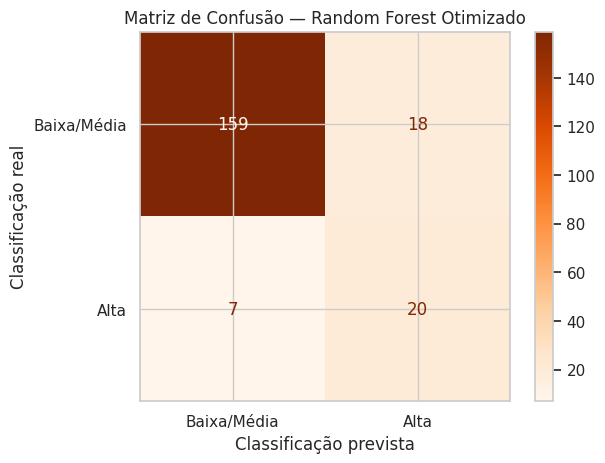

In [143]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_modelo_final,
    display_labels=[
        'Baixa/Média',
        'Alta'
    ],
    cmap='Oranges',
    values_format='d'
)

plt.title(
    'Matriz de Confusão — Random Forest Otimizado'
)

plt.xlabel('Classificação prevista')
plt.ylabel('Classificação real')
plt.show()

## | Curva ROC

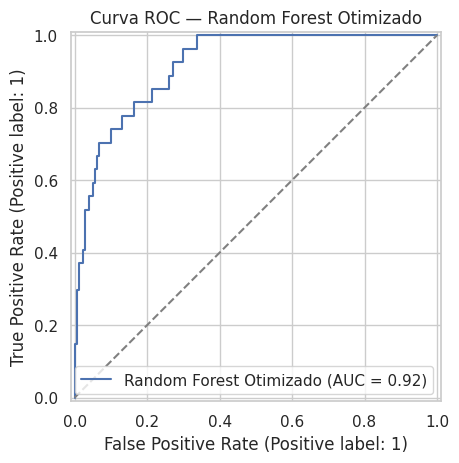

In [144]:
RocCurveDisplay.from_predictions(
    y_teste,
    y_prob_modelo_final,
    name='Random Forest Otimizado'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.title(
    'Curva ROC — Random Forest Otimizado'
)

plt.show()

## | Variáveis mais Relevantes

,variavel,importancia_media,desvio
10,alcohol,0.0757,0.0231
9,sulphates,0.0579,0.0158
1,volatile_acidity,0.0338,0.0166
6,total_sulfur_dioxide,0.0059,0.0062
2,citric_acid,0.0050,0.0047
8,ph,0.0019,0.0023
3,residual_sugar,0.0003,0.0024
4,chlorides,-0.0000,0.0011
0,fixed_acidity,-0.0004,0.0018
7,density,-0.0006,0.0054


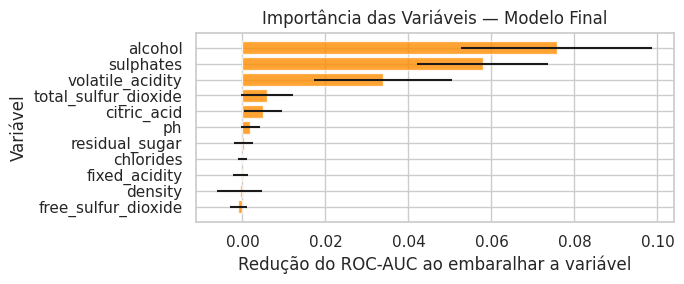

In [145]:
from sklearn.inspection import permutation_importance

importancia_permutacao = permutation_importance(
    estimator=modelo_final,
    X=X_teste,
    y=y_teste,
    scoring='roc_auc',
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importancia_modelo_final = pd.DataFrame({
    'variavel': X_teste.columns,

    'importancia_media':
        importancia_permutacao.importances_mean,

    'desvio':
        importancia_permutacao.importances_std
}).sort_values(
    by='importancia_media',
    ascending=False
)

display(
    importancia_modelo_final.style.format({
        'importancia_media': '{:.4f}',
        'desvio': '{:.4f}'
    })
)


# Gráfico
importancia_grafico = (
    importancia_modelo_final
    .sort_values(
        by='importancia_media',
        ascending=True
    )
)

plt.figure(figsize=(7, 3))

plt.barh(
    importancia_grafico['variavel'],
    importancia_grafico['importancia_media'],
    xerr=importancia_grafico['desvio'],
    color='darkorange',
    alpha=0.8
)

plt.title(
    'Importância das Variáveis — Modelo Final'
)

plt.xlabel(
    'Redução do ROC-AUC ao embaralhar a variável'
)

plt.ylabel('Variável')
plt.tight_layout()
plt.show()

Nota:

O Random Forest otimizado apresentou acurácia de 87,75% e ROC-AUC de 91,82%. Entre os 27 vinhos de alta qualidade do conjunto de teste, o modelo conseguiu identificar 20, alcançando recall de 74,07%. A precisão ficou em 52,63%, o que mostra que pouco mais da metade dos vinhos classificados como alta qualidade realmente pertencia a essa categoria. Mesmo com essa limitação, o modelo apresentou o melhor equilíbrio entre precisão e recall, alcançando F1-score de 61,54%.


Importância das Variáveis:

A análise de importância por permutação mostrou que álcool, sulfatos e acidez volátil foram as características que mais contribuíram para o resultado do modelo. O dióxido de enxofre total e o ácido cítrico também apresentaram alguma influência, mas em menor intensidade. Esses resultados indicam quais variáveis merecem maior atenção durante a análise exploratória, mas não comprovam que elas causam diretamente o aumento ou a redução da qualidade do vinho.

## || Conclusão da Modelagem

Após testar Regressão Logística, KNN, SVM e Random Forest, foram realizadas validação cruzada, criação de novas features, seleção de variáveis, divisão das características em faixas e otimização dos parâmetros. O Random Forest com cinco faixas criadas por K-Means e 500 árvores apresentou o melhor resultado geral. Dessa forma, ele foi escolhido como modelo final para apoiar a identificação de vinhos com maior potencial de qualidade.

### || Aplicação no negócio

O modelo deve ser utilizado como apoio à triagem, ajudando a priorizar amostras com maior potencial de qualidade para avaliação dos especialistas. Álcool, sulfatos e acidez volátil podem ser acompanhados durante o processo produtivo, mas não devem ser interpretados isoladamente nem como causas diretas da qualidade.

## || Nota Final:

Os resultados do modelo estão alinhados com a análise exploratória. Álcool, sulfatos e acidez volátil foram as variáveis mais importantes para o Random Forest e também apresentaram diferenças relevantes entre as duas classes. Os vinhos de alta qualidade possuem, em média, maior teor alcoólico e maiores níveis de sulfatos, além de menor acidez volátil. Mesmo assim, existe uma sobreposição relevante entre os grupos, mostrando que a qualidade depende da combinação de várias características.

## || Conclusão Final

A análise exploratória mostrou que a base possui um desbalanceamento relevante, com apenas 13,46% dos registros classificados como alta qualidade. Também foram encontradas distribuições assimétricas e valores extremos, principalmente em açúcar residual e cloretos, que foram mantidos por representarem possíveis características reais dos vinhos. As variáveis com maior associação à qualidade foram: Álcool, sulfatos, ácido cítrico e acidez volátil. Esses resultados orientaram a escolha das métricas, o teste de diferentes técnicas de feature engineering e a utilização de modelos capazes de identificar relações não lineares.